### Reading MATPOWER files

In [1]:
using PowerModels
using JuMP,Gurobi, DataFrames, XLSX,Random,Distributions
# Specify the path to your MATPOWER file
file_path = "/Users/Patron/Documents/Switch_Instances/case118Blumsack.m"
file_path_excel = "/Users/Patron/Documents/Switch_Instances/RandomDemands.xlsx"

# Parse the MATPOWER case file
network = PowerModels.parse_file(file_path);

# Read the Excel data containing random parameters 
param_data = XLSX.readtable(file_path_excel, "118_15") |> DataFrame;

[warn | PowerModels]: this code only supports angmin values in -90 deg. to 90 deg., tightening the value on branch 1 from -360.0 to -60.0 deg.
[warn | PowerModels]: this code only supports angmax values in -90 deg. to 90 deg., tightening the value on branch 1 from 360.0 to 60.0 deg.
[warn | PowerModels]: this code only supports angmin values in -90 deg. to 90 deg., tightening the value on branch 54 from -360.0 to -60.0 deg.
[warn | PowerModels]: this code only supports angmax values in -90 deg. to 90 deg., tightening the value on branch 54 from 360.0 to 60.0 deg.
[warn | PowerModels]: this code only supports angmin values in -90 deg. to 90 deg., tightening the value on branch 101 from -360.0 to -60.0 deg.
[warn | PowerModels]: this code only supports angmax values in -90 deg. to 90 deg., tightening the value on branch 101 from 360.0 to 60.0 deg.
[warn | PowerModels]: this code only supports angmin values in -90 deg. to 90 deg., tightening the value on branch 41 from -360.0 to -60.0 deg

### Graph 

┌ Warning: Module DataStructures with build ID fafbfcfd-66f0-0035-0000-013aae262dfb is missing from the cache.
│ This may mean DataStructures [864edb3b-99cc-5e75-8d2d-829cb0a9cfe8] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module DataStructures with build ID fafbfcfd-66f0-0035-0000-013aae262dfb is missing from the cache.
│ This may mean DataStructures [864edb3b-99cc-5e75-8d2d-829cb0a9cfe8] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module DataStructures with build ID fafbfcfd-66f0-0035-0000-013aae262dfb is missing from the cache.
│ This may mean DataStructures [864edb3b-99cc-5e75-8d2d-829cb0a9cfe8] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module StatsBase with build ID fafbfcfd-53eb-557b-0000-031aafc1124f is missing from the cache.
│ This may mean StatsBase [2913bbd2-ae8a-5f71-8c99-4fb6c76f3a91

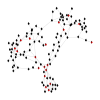

In [14]:
using Graphs
using GraphPlot
using Plots

"""
    build_network_graph(data)

Constructs an undirected graph where nodes represent buses and edges represent transmission lines.
`data` is assumed to be a dictionary with keys "bus", "branch", and "gen" as provided by MATPOWER / PowerModels.
"""
function build_network_graph(data)
    # Get all bus IDs (assumed to be keys in data["bus"] as strings)
    bus_ids = [parse(Int, bus_id) for bus_id in keys(data["bus"])]
    n = maximum(bus_ids)  # total number of buses (assumes bus IDs are contiguous or at least max gives n)
    g = Graph(n)  # create an undirected graph with n nodes

    # Add edges: each branch connects f_bus and t_bus
    for (branch_id, branch) in data["branch"]
        f_bus = branch["f_bus"]
        t_bus = branch["t_bus"]
        # Add an edge if it doesn't already exist (Graph.jl ignores duplicate edges)
        add_edge!(g, f_bus, t_bus)
    end
    return g
end

"""
    plot_network_graph(data)

Builds the network graph, computes connected components, and then plots the graph.
- Nodes are colored based on connected component membership.
- Generator nodes (from data["gen"]) are highlighted (e.g. using red).
- Node labels show the connected component index.
"""
function plot_network_graph(data)
    # Build the network graph
    g = build_network_graph(data)
    
    # Compute connected components (each component is a vector of node indices)
    comps = connected_components(g)
    num_comps = length(comps)
    
    # Create a mapping from node to its connected component index.
    comp_index = Dict{Int, Int}()
    for (idx, comp) in enumerate(comps)
        for node in comp
            comp_index[node] = idx
        end
    end

    # Identify generator nodes (assuming each generator has key "gen_bus")
    gen_buses = Int[]
    for (_gen_id, gen) in data["gen"]
        push!(gen_buses, gen["gen_bus"])
    end

    # Generate a color palette for components (one color per component)
    palette = distinguishable_colors(num_comps)
    
    n = nv(g)
    # Assign each node a color based on its connected component.
    # If a node is a generator, override its color with red.
    node_colors = [in(i, gen_buses) ? "red" : palette[comp_index[i]] for i in 1:n]
    
    # Optionally, label nodes with their component number
    node_labels = [string(comp_index[i]) for i in 1:n]
    
    # Plot using GraphPlot.gplot.
    # The graph layout is computed automatically; you can also choose a layout (like spring_layout)
    gplot(g,nodelabel = node_labels,nodefillc = node_colors )  # set curvesteps=0 for straight edges
end

# Example usage:
# Assuming `data` is already loaded from your MATPOWER case via PowerModels,
# e.g., data = PowerModels.parse_file("case118.m")
# Then plot the network:
plot_network_graph(network)


In [64]:
center_data = [56 27 42 50 0 59 29 40 0 0 80 56 46 17 99 37 24 69 56 25 16 23 7 20 0 0 83 31 28 0 47 65 29 71 35 32 0 0 39 74 48 111 31 30 65 40 42 35 88 24 27 28 24 124 70 88 22 25 278 92 0 83 0 0 0 47 41 0 0 75 0 20 21 75 47 72 76 79 46 130 0 65 33 23 24 32 0 63 0 450 19 79 26 45 44 42 17 42 57 38 24 10 38 51 33 46 51 6 13 51 0 73 13 18 23 199 22 42];


In [65]:
center_data = 0.01.*collect(center_data[1,:]);

### Generating parameters

In [66]:
function parameters(network)
    #Sets
    B = network["bus"]
    L = network["branch"]
    G = network["gen"]

    #Parameters
    B_ij = zeros(length(L)) # Suspectance valuesL
    fbar_ij = zeros(length(L)) # Upper bound on the load
    p_max = zeros(length(B)) #Max power ouput
    p_min = zeros(length(B)) #Min power output
    c = zeros(length(B)) #Linear Cost coefficient with zero intercept

    for (branch_id,branch) in L
        B_ij[parse(Int,branch_id)] = -branch["br_x"]/(branch["br_r"]^2 + branch["br_x"]^2)  # B_ij = -reactance/(resistance^2+reactance^2)
        fbar_ij[parse(Int,branch_id)] = branch["rate_a"]   #f_max = rate A
    end

    for (gen_id,generator) in G
        c[generator["gen_bus"]] = generator["cost"][1]    #generator linear cost funcion slope with 0 intercept
        p_max[generator["gen_bus"]] = generator["pmax"]     # max power 
        p_min[generator["gen_bus"]] = generator["pmin"]     # min power
    end
    n = 2*length(network["bus"])        # Number of rows
    m = length(network["branch"])     # Number of columns

    # Initialize matrix
    A = zeros(n, m)

    # Create A
    for (branch_id, branch) in L
        f_bus = branch["f_bus"]  # From bus
        t_bus = branch["t_bus"]  # To bus

        # Update incidence matrix
        branch_index = parse(Int,branch_id)
        A[2*f_bus-1, branch_index] = 1   # From bus
        A[2*f_bus, branch_index] = -1 # From bus
        A[2*t_bus-1, branch_index] = -1  # To bus
        A[2*t_bus, branch_index] = 1  # To bus
    end

    return B_ij,fbar_ij,p_max,p_min, A,c
end

parameters (generic function with 1 method)

### Offline calculations

In [67]:
function offline_calc(data, center_data)
    #Initialize the model
    model = Model(Gurobi.Optimizer)
    MOI.set(model, MOI.TimeLimitSec(), 60.0)

    #Sets
    B = data["bus"]
    L = data["branch"]
    G = data["gen"]

    #Decision Variables
    @variable(model, theta[1: length(B)])  # Voltage angle decision variable
    @variable(model, f[1:length(L)]) # Current flow decision variable 
    @variable(model, x[1:length(L)],Bin) # Switching decision variable
    @variable(model, unmet[1:2*length(B)]>=0)
    Penalty = 10000
    penalty_flag = 0

    n = 2*length(data["bus"])        # Number of rows
    b = zeros(n)
    
    B_ij,f_ij,p_max,p_min, A,c_i = parameters(data)
    Pd = center_data
        

    #Create b
    for (bus_id, bus) in B
        bus_index = parse(Int,bus_id)
        b[2*bus_index-1] = p_min[bus_index] - Pd[bus_index]
        b[2*bus_index] = -p_max[bus_index] + Pd[bus_index]
    end

    #Objective Expression
    objective = 0.0
    for (gen_id,generator) in G
        #Generator index
        gen_index = generator["gen_bus"]
        sum_fij=0.0
        sum_fji=0.0
        for (branch_id,branch) in L
            branch_index = parse(Int,branch_id)
            if branch["f_bus"] == gen_index
                sum_fij += f[branch_index]
            end
            if branch["t_bus"] == gen_index
                sum_fji += f[branch_index]
            end
        end
        objective += c_i[gen_index]*(Pd[gen_index] + sum_fij - sum_fji)
    end
    objective += Penalty*sum(unmet[i] for i in 1:2*length(B))
    
    # Constraints
    
    @constraint(model, A * f + unmet .>= b)
    #@constraint(model, [i = 1:length(L)], x[i] <= 1)
    for (branch_id,branch) in L
        branch_index = parse(Int,branch_id)
        f_bus = branch["f_bus"]
        t_bus = branch["t_bus"]
        M_ij = -12.6*B_ij[branch_index]
        @constraint(model,-f[branch_index] - f_ij[branch_index]*x[branch_index]<=0)
        @constraint(model,f[branch_index] - f_ij[branch_index]*x[branch_index]<=0)
    
        # Linearizing them
        @constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-x[branch_index])-f[branch_index]<=0)
        @constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-x[branch_index])+f[branch_index]<=0)

        #Trying larger big-M values
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])-f[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])+f[branch_index]<=0)
    end

    # Define the objective function
    @objective(model, Min, objective)
    
   
    optimize!(model)
    

    if termination_status(model) == MOI.OPTIMAL
        if sum(value.(unmet)) >= 0.000001
            penalty_flag = 1
        end
        result = value.(x)
        return objective_value(model),collect(value.(x)),penalty_flag
    else
        return -1,[],-1
    end
end

offline_calc (generic function with 1 method)

In [62]:
offline_calc(network, center_data)

(3037.3855155779725, [1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0], 0)

### Scenario Generation

In [36]:
function generate_scenarios(demand_data,numscenarios)
    samples = zeros(numscenarios,length(center_data))
    # Global min
    #global_min = minimum(center_data)
    #global_max = maximum(center_data)
    
    for scenario in 1:numscenarios
        #global_value = round(rand(Uniform(global_min, global_max)),digits=0)  # Global value
        global_factor = rand(Uniform(0.8, 1.2)) #Global factor
        for i in 1:length(center_data)
            center = center_data[i]
            if center == 0
                #min_val = 0
                #max_val = 1  # Default range for zero-center buses
                local_factor_i = rand(Uniform(0,1))
            else
            #min_val = max(0, center * 0.80)  # 20% below center
            #max_val = center * 1.2         # 20% above center
                local_factor_i = 1 + rand(Uniform(-0.1, 0.1))  # ±20% local
            end
            bus_demand_i = center_data[i] * 1 * local_factor_i
            samples[scenario,i] = bus_demand_i
            #samples[scenario,i]= round(rand(Uniform(min_val, max_val))*(1+(global_value*0.0)/global_max),digits=0)
        end
    end
    return samples
end  

generate_scenarios (generic function with 1 method)

### Sampling

In [37]:
function sampling_for_offline_calc(
    network,
    demand_data::AbstractVector{<:Real},
    total_scenarios::Integer;
    capacity_factor::Real = 1.20  

)
    # 1) unpack network parameters
    B_ij,fbar_ij,p_max_base,p_min_base, A,c = parameters(network)

    # index sets
    buses    = sort(parse.(Int, collect(keys(network["bus"]))))
    branches = sort(parse.(Int, collect(keys(network["branch"]))))
    nb       = length(buses)
    nl       = length(branches)


    # 2) pre-allocate storage
    demand_samples = zeros(Float64,      total_scenarios, nb)
    x_solutions    = zeros(total_scenarios, nl)

    # 3) sampling loop
    found = 0
    while found < total_scenarios
        # generate one draw of demand & cost
        ds = generate_scenarios(demand_data, 1)
        #print(ds)
        #d = vec(ds[1, :])   # demand scenario

        # make *local* scaled copies of your capacities
        p_max = p_max_base .* capacity_factor
        p_min = p_min_base .* capacity_factor

        # try to solve
        obj,x,p = offline_calc(network,generate_scenarios(demand_data, 1))

        # if we get here, it solved to optimality
        if obj!=-1
            found += 1
            demand_samples[found, :] = ds
            x_solutions[found, :] = x

        else
            println("Scenario is infeasible, trying again")
            # just loop and sample again
        end
    end

    return demand_samples, x_solutions
end
demand_samples,x_solutions=sampling_for_offline_calc(network,center_data,20)

Set parameter Username
Set parameter LicenseID to value 2686057
Academic license - for non-commercial use only - expires 2026-07-09
Set parameter TimeLimit to value 60
Set parameter TimeLimit to value 60
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.6.0 23H626)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  60

Optimize a model with 980 rows, 726 columns and 3212 nonzeros
Model fingerprint: 0xdc5614ad
Variable types: 540 continuous, 186 integer (186 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [6e-02, 1e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-02, 3e+03]
Found heuristic solution: objective 442771.69293
Found heuristic solution: objective 442771.69150
Presolve removed 181 rows and 40 columns
Presolve time: 0.01s
Presolved: 799 rows, 686 columns, 2644 nonzeros
Found heuristic solution: objective 422755.42132
Variable

([0.6029331897265549 0.28285259838961035 … 0.2103731375235703 0.4412042460858046; 0.5994237926606961 0.2453570915182453 … 0.216726200545513 0.42431823974738386; … ; 0.581777802834806 0.2731598916564296 … 0.19909342238466618 0.39071434927588217; 0.5902126366199075 0.2767185521627233 … 0.1999103698137447 0.44755229202787167], [1.0 1.0 … 1.0 -0.0; -0.0 1.0 … -0.0 1.0; … ; 1.0 1.0 … 1.0 0.0; 1.0 1.0 … 1.0 1.0])

In [38]:
online_samples = generate_scenarios(center_data,200);

In [39]:
function solve_for_continuous_var(data,sample,solved_x)
    #Initialize the model
    model = Model(Gurobi.Optimizer)
    MOI.set(model, MOI.TimeLimitSec(), 300.0)

    #Sets
    B = data["bus"]
    L = data["branch"]
    G = data["gen"]

    #Decision Variables
    @variable(model, theta[1: length(B)])  # Voltage angle decision variable
    @variable(model, f[1:length(L)]) # Current flow decision variable 
    @variable(model, unmet[1:2*length(B)]>=0)
    #@variable(model, v[1:2*length(B)])
    #@variable(model, delta1[1:length(L)]>=0)
    #@variable(model, delta2[1:length(L)]>=0)
    #for i in 1:length(B)
    #    @constraint(model, v[2*i-1] == -unmet[i])
    #    @constraint(model, v[2*i]   ==  unmet[i])
    #end

    #Parameters
    Pd = zeros(length(B)) #Demand values
    B_ij = zeros(length(L)) # Suspectance valuesL
    f_ij = zeros(length(L)) # Upper bound on the load
    c_i = zeros(length(B)) #Linear Cost coefficient with zero intercept
    p_max = zeros(length(B)) #Max power ouput
    p_min = zeros(length(B)) #Min power output
    Penalty = 10000

    #Select demand parameter
    #num_rows = size(param_data,1)
    #random_index = 2
    #random_index = rand(1:num_rows)
    Pd = sample

    for (branch_id,branch) in L
        B_ij[parse(Int,branch_id)] = -branch["br_x"]/(branch["br_r"]^2 + branch["br_x"]^2)  # B_ij = -reactance/(resistance^2+reactance^2)
        f_ij[parse(Int,branch_id)] = branch["rate_a"]   #f_max = rate A
    end

    for (gen_id,generator) in G
        c_i[generator["gen_bus"]] = generator["cost"][1]    #generator linear cost funcion slope with 0 intercept
        p_max[generator["gen_bus"]] = generator["pmax"]     # max power 
        p_min[generator["gen_bus"]] = generator["pmin"]
    end

        

    n = 2*length(data["bus"])        # Number of rows
    m = length(data["branch"])     # Number of columns

    # Initialize matrix
    A = zeros(n, m)
    b = zeros(n)
    
    # Create A
    for (branch_id, branch) in L
        f_bus = branch["f_bus"]  # From bus
        t_bus = branch["t_bus"]  # To bus

        # Update incidence matrix
        branch_index = parse(Int,branch_id)
        A[2*f_bus-1, branch_index] = 1   # From bus
        A[2*f_bus, branch_index] = -1 # From bus
        A[2*t_bus-1, branch_index] = -1  # To bus
        A[2*t_bus, branch_index] = 1  # To bus
    end
        

    #Create b
    for (bus_id, bus) in B
        bus_index = parse(Int,bus_id)
        b[2*bus_index-1] = p_min[bus_index] - Pd[bus_index] 
        b[2*bus_index] = -p_max[bus_index] + Pd[bus_index]
    end

    #Objective Expression
    objective = 0.0
    for (gen_id,generator) in G
        #Generator index
        gen_index = generator["gen_bus"]
        sum_fij=0.0
        sum_fji=0.0
        for (branch_id,branch) in L
            branch_index = parse(Int,branch_id)
            if branch["f_bus"] == gen_index
                sum_fij += f[branch_index]
            end
            if branch["t_bus"] == gen_index
                sum_fji += f[branch_index]
            end
        end
        objective += c_i[gen_index]*(Pd[gen_index] + sum_fij - sum_fji)
    end
    
    
    objective += Penalty*sum(unmet[i] for i in 1:2*length(B))
    

    # Constraints
    @constraint(model, A * f + unmet  .>= b )

    for (branch_id,branch) in L
        branch_index = parse(Int,branch_id)
        f_bus = branch["f_bus"]
        t_bus = branch["t_bus"]
        M_ij = -12.6*B_ij[branch_index]
        @constraint(model,-f[branch_index] - f_ij[branch_index]*solved_x[branch_index]<=0)
        @constraint(model,f[branch_index] - f_ij[branch_index]*solved_x[branch_index]<=0)
    
        # Non linear constraints
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus])*x[branch_index]-f[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus])*x[branch_index]+f[branch_index]<=0)
    
        # Linearizing them
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-solved_x[branch_index])-f[branch_index] - delta1[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-solved_x[branch_index])+f[branch_index] - delta2[branch_index]<=0)
        @constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-solved_x[branch_index])-f[branch_index]  <=0)
        @constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-solved_x[branch_index])+f[branch_index]  <=0)

        #Trying larger big-M values
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])-f[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])+f[branch_index]<=0)
    end

    # Define the objective function
    @objective(model, Min, objective)
    
    # Solve the model
    set_silent(model)
    optimize!(model)
    # If the model is infeasible, compute the IIS
    if termination_status(model) == MOI.INFEASIBLE_OR_UNBOUNDED
        println("⚠️ Model is infeasible! Running IIS analysis...")
        compute_conflict!(model)  # Extract the conflict set

        # Print conflicting constraints
        println("Identified infeasible constraints:")
        for (F, S) in list_of_constraint_types(model)
            for (i, constr) in enumerate(all_constraints(model, F, S))
                status = MOI.get(model, MOI.ConstraintConflictStatus(), constr)  # Correct function
                if status == MOI.IN_CONFLICT
                    println("🔴 Constraint $i is in the IIS: ", constr)
                end
            end
        end
    end

    # Check solver status
    if termination_status(model) == MOI.OPTIMAL
        return objective_value(model),collect(value.(f))
    else
        return -1,[]
    end
end   

solve_for_continuous_var (generic function with 1 method)

In [40]:
function Calculations_For_Extensive_Form(data,online_samples,S,l,x_chosen)
    L = data["branch"]
    solved_x = [Vector{Float64}[] for _ in 1:S]
    obj_value = zeros(S,l)
    for (i,sample) in zip(1:S,eachrow(online_samples))
        solved_x[i] = [zeros(length(L)) for _ in 1:l]
        for solution in 1:l
            obj_value[i,solution],solved_x[i][solution] = solve_for_continuous_var(data,sample,x_chosen[solution,:])
        end
    end
    return obj_value,solved_x
end
obj_value,solved_x = Calculations_For_Extensive_Form(network,online_samples,200,20,x_solutions);

Excessive output truncated after 556223 bytes.

In [41]:
function Reformulated_Extensive_Form(S,l,K,obj_value)
    # Initialize model
    model = Model(Gurobi.Optimizer)
    MOI.set(model, MOI.TimeLimitSec(), 3600.0)

    #Total scenarios

    # Decision Variables
    @variable(model, z[1:l], Bin)
    @variable(model, w[1:l , 1:S], Bin)

    # Constraints
    for scenario in 1:S
        for solution in 1:l
            if obj_value[scenario,solution] == -1
                @constraint(model, w[solution,scenario] == 0)   ## weights of infeasible scenario/first stage decision pair is 0
            end
        end
    end
            
        
    for j in 1:S
        @constraint(model, [i in 1:l], w[i,j] <= z[i])
        @constraint(model, sum(w[i,j] for i in 1:l) == 1)
    end
    @constraint(model, sum(z[i] for i in 1:l) <= K)

    # Objective
    objective = 0.0
    for scenario in 1:S
        for solution in 1:l
            objective += w[solution,scenario]*obj_value[scenario,solution]
        end
    end

    # Define the objective function
    @objective(model, Min, objective/S)

    # Solve the model
    #set_silent(model)
    optimize!(model)
    # Check solver status

    if termination_status(model) == MOI.OPTIMAL
        #println("Optimal solution found.")
        #println("Objective value: ", objective_value(model))
        #println("Time taken to solve:",solve_time(model)," seconds")
        return objective_value(model),value.(z),solve_time(model)
    else
        #println("Solver did not find an optimal solution.")
        return -1,[],-1
    end    
end 
Solution,z,time=Reformulated_Extensive_Form(200,20,10,obj_value)

(3134.97477890411, [-0.0, -0.0, 1.0, 1.0, -0.0, 1.0, -0.0, 1.0, 1.0, -0.0, -0.0, 1.0, -0.0, -0.0, 1.0, 0.0, 1.0, -0.0, 1.0, 1.0], 0.018862009048461914)

### Partitions

In [136]:
"""
Assign each online scenario to the selected offline policies.

# Arguments
- `network`        : PowerModels network dictionary
- `x_solutions`    : Matrix (l × n_branches), each row is a first‐stage binary switching solution
- `z`              : Vector length l; treats entries ≥0.5 as “selected” policies
- `online_samples` : Matrix (S × n_buses), each row is a demand sample

# Returns
- `partitions` : Vector of length K, where each entry is a Vector{Int}
                 listing the scenario‐indices assigned to that policy
"""
function assign_partitions(network::Dict,
                           x_solutions::AbstractMatrix{<:Real},
                           z::AbstractVector,
                           online_samples::AbstractMatrix{<:Real})
    # determine which policies are active
    selected_indices = findall(v -> v ≥ 0.5, z)
    K = length(selected_indices)
    S = size(online_samples, 1)

    # prepare output
    partitions = [Int[] for _ in 1:K]

    # for each scenario, pick the best selected policy
    for j in 1:S
        sample = online_samples[j, :]
        best_val = Inf
        best_k   = 0
        for (k_idx, sol_idx) in enumerate(selected_indices)
            val, _ = solve_for_continuous_var(network, sample, x_solutions[sol_idx, :])
            if val < best_val
                best_val = val
                best_k   = k_idx
            end
        end
        push!(partitions[best_k], j)
    end

    return partitions
end
parts = assign_partitions(network, x_solutions, z, online_samples)


Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit

15-element Vector{Vector{Int64}}:
 [12, 27, 50, 55, 56, 57, 58, 62, 65, 66  …  93, 96, 105, 107, 113, 129, 176, 177, 188, 195]
 [6, 9, 20, 37, 43, 45, 59, 64, 68, 70  …  122, 127, 133, 135, 150, 167, 170, 186, 198, 200]
 [7, 13, 26, 36, 38, 53, 84, 99, 102, 110, 142, 147, 158, 160, 164, 165, 173, 194, 196]
 [1, 47, 74, 91, 97, 156, 162, 187, 197]
 [24, 34, 52, 63, 67, 69, 76, 104, 108, 116, 119, 139, 141, 159, 184, 189]
 [4, 8, 23, 25, 31, 51, 60, 73, 83, 94, 115, 121, 132, 137, 145, 171, 179, 182, 185, 190]
 [5, 15, 16, 19, 22, 35, 39, 48, 49, 85, 95, 124, 128, 146, 169, 175, 191, 199]
 [11, 14, 44, 71, 130, 157, 161, 174]
 [10, 18, 30, 32, 61, 77, 118, 120, 125, 134, 151, 193]
 [28, 117, 140, 143, 149, 163, 168, 172, 180]
 [46, 111, 123, 144, 148, 153, 155]
 [3, 42]
 [2, 17, 40, 100, 114, 126, 131, 136]
 [29, 33, 41, 82, 87, 92, 152, 154, 166, 178, 181]
 [21, 54, 79, 88, 98, 138, 183, 192]

et parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expire

### Augmentation Heuristic

In [270]:
function AugmentationHeuristic(network,
                               online_samples,
                               initial_L;
                               K::Int=5,
                               capacity_factor::Float64=1.0,
                               tol::Float64=1e-6,
                               max_iters::Int=10,
                               benders_opts::Dict=Dict())
    # current policy library
    L = copy(initial_L)
    m = size(initial_L, 2)

    for iter in 1:max_iters
        L_prev = copy(L)

        # 4. Select K policies via extensive-form reformulation
        z = select_policies(network, L_prev, online_samples, K)

        # 5. Partition scenarios for those K policies
        partitions = assign_partitions(
            network,
            L_prev,
            z,
            online_samples
        )

        # 8. Run Benders on each partition to generate new candidates
        Y_new = run_all_benders(
            network,
            partitions,
            online_samples;
            capacity_factor=capacity_factor,
            K_max=K,
            tol=tol,
            max_iters=get(benders_opts, :max_iters, 50)
        )

        # 11. Augment library and deduplicate
        L = unique(vcat(L_prev, Y_new), dims=1)

        # stop if no new policies added
        if size(L,1) == size(L_prev,1)
            break
        end
    end

    # final selection on augmented library
    z_final = select_policies(network, L, online_samples, K)
    selected_indices = findall(z_final .== 1)
    return L[selected_indices, :]
end

# Example call:
 Y_final = AugmentationHeuristic(
     network,
     online_samples,
     x_solutions;
     K=10,
     capacity_factor=1.2,
     tol=1e-6,
     max_iters=30,
     benders_opts=Dict(:max_iters=>30)
 )


Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit

10×186 Matrix{Float64}:
  1.0   1.0   1.0  -0.0   1.0   1.0  1.0  …   1.0  1.0  1.0  1.0   1.0   1.0
  1.0   1.0   1.0   1.0   0.0   1.0  1.0      1.0  1.0  1.0  1.0   0.0   0.0
  1.0   1.0  -0.0   1.0  -0.0   1.0  1.0      1.0  1.0  1.0  1.0  -0.0   0.0
 -0.0   1.0   1.0   1.0  -0.0   1.0  1.0     -0.0  1.0  1.0  1.0   1.0   1.0
  1.0   1.0  -0.0   1.0  -0.0  -0.0  1.0      1.0  1.0  1.0  1.0  -0.0  -0.0
  1.0   0.0   1.0   1.0   1.0   1.0  1.0  …  -0.0  1.0  1.0  1.0   1.0   1.0
  1.0   1.0  -0.0   1.0   1.0   1.0  1.0      1.0  1.0  1.0  1.0   1.0   1.0
  1.0  -0.0   1.0   1.0  -0.0   1.0  1.0     -0.0  1.0  1.0  1.0  -0.0   1.0
  1.0   1.0  -0.0   1.0   1.0   1.0  1.0     -0.0  1.0  1.0  1.0  -0.0   1.0
  1.0  -0.0   1.0   1.0   1.0   1.0  1.0      1.0  1.0  1.0  1.0   1.0   1.0

et parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expire

### Benders

In [160]:
function Benders_DCOTS(network::Dict,
                       partition::Vector{Int},
                       online_samples::Matrix{Float64};
                       capacity_factor::Float64=1.0,
                       K_max::Int=length(partition),
                       tol::Float64=1e-6,
                       max_iters::Int=50)

    # unpack network data
    B_ij, fbar_ij, p_max_base, p_min_base, A, c = parameters1(network)
    n = size(A,1) ÷ 2
    m = length(fbar_ij)
    S = length(partition)
    samples = online_samples[partition, :]
    Penalty = 1e4

    # build master
    master = Model(Gurobi.Optimizer)
    @variable(master, x[1:m], Bin)
    @variable(master, θm[1:S] >= 0)
    @constraint(master, sum(x) <= K_max)
    @objective(master, Min, sum(θm[s] for s in 1:S)/S)

    for iter in 1:max_iters
        # solve master
        optimize!(master)
        x_bar = value.(x)
        θ_bar = value.(θm)

        cuts_added = 0

        # solve each subproblem
        for s_idx in 1:S
            Pd = samples[s_idx, :]

            sub = Model(Gurobi.Optimizer)
            @variable(sub, θs[1:n])
            @variable(sub, fs[1:m])
            @variable(sub, unmet[1:2*n] >= 0)

            # balance constraints with penalty slack
            balance = Vector{ConstraintRef}(undef, 2*n)
            for i in 1:n
                b_lo = p_min_base[i]*capacity_factor - Pd[i]
                b_hi = -p_max_base[i]*capacity_factor + Pd[i]
                balance[2*i-1] = @constraint(sub,
                    sum(A[2*i-1,k]*fs[k] for k in 1:m) + unmet[2*i-1] >= b_lo)
                balance[2*i]   = @constraint(sub,
                    sum(A[2*i,  k]*fs[k] for k in 1:m) + unmet[2*i]   >= b_hi)
            end

            # flow & angle constraints
            cap1 = Vector{ConstraintRef}(undef, m)
            cap2 = Vector{ConstraintRef}(undef, m)
            lin1 = Vector{ConstraintRef}(undef, m)
            lin2 = Vector{ConstraintRef}(undef, m)
            for k in 1:m
                M = -12.6 * B_ij[k]
                cap1[k] = @constraint(sub, -fs[k] - fbar_ij[k]*x_bar[k] <= 0)
                cap2[k] = @constraint(sub,  fs[k] - fbar_ij[k]*x_bar[k] <= 0)

                br = network["branch"][string(k)]
                fbus, tbus = br["f_bus"], br["t_bus"]
                lin1[k] = @constraint(sub,
                    B_ij[k]*(θs[fbus] - θs[tbus]) - M*(1 - x_bar[k]) - fs[k] <= 0)
                lin2[k] = @constraint(sub,
                    -B_ij[k]*(θs[fbus] - θs[tbus]) - M*(1 - x_bar[k]) + fs[k] <= 0)
            end

            # objective with unmet penalty
            @objective(sub, Min,
                sum(c[i]*(Pd[i]
                    + sum(fs[j] for j=1:m
                        if network["branch"][string(j)]["f_bus"] == i)
                    - sum(fs[j] for j=1:m
                        if network["branch"][string(j)]["t_bus"] == i)
                ) for i in 1:n)
                + Penalty * sum(unmet)
            )

            optimize!(sub)
            Qs = objective_value(sub)

            if Qs > θ_bar[s_idx] + tol
                cuts_added += 1

                # collect duals
                π  = dual.(balance)
                μ1 = dual.(cap1); μ2 = dual.(cap2)
                λ1 = dual.(lin1); λ2 = dual.(lin2)

                # constant term
                rhs = sum(
                    π[t] * ( if t % 2 == 1
                                p_min_base[(t+1)÷2]*capacity_factor - Pd[(t+1)÷2]
                            else
                                -p_max_base[t÷2]*capacity_factor + Pd[t÷2]
                            end )
                    for t in 1:2*n
                )

                # x-coefficients
                α = [
                    μ1[k]*fbar_ij[k] + μ2[k]*fbar_ij[k] +
                    (λ1[k] + λ2[k]) * (-12.6 * B_ij[k])
                    for k in 1:m
                ]

                @constraint(master,
                    θm[s_idx] - sum(α[k]*x[k] for k in 1:m) >= rhs
                )
            end
        end

        # if no cuts added, x_bar is optimal
        if cuts_added == 0
            return Int.(round.(value.(x)))
        end
    end

    # final solve to clear any pending modifications
    optimize!(master)
    return Int.(round.(value.(x)))
end

# Example call:
#x_star = Benders_DCOTS(network, partitions[1], online_samples;
#                        capacity_factor=1.0, K_max=5, tol=1e-6, max_iters=50)

Benders_DCOTS (generic function with 1 method)

### Run All Benders

In [158]:
# Function to run Benders_DCOTS on all partitions and collect results

"""
Run Benders_DCOTS for each partition and return a matrix of switch vectors.

# Arguments
- `network`         : PowerModels network dictionary
- `partitions`      : Vector of partitions (each is a Vector{Int} of scenario indices)
- `online_samples`  : Matrix (S × n_buses) of demand samples

# Keyword Arguments
- `capacity_factor` : scale factor for generator capacities (default = 1.0)
- `K_max`           : max number of line switches allowed per run (default = 5)
- `tol`             : Benders tolerance (default = 1e-6)
- `max_iters`       : max Benders iterations (default = 50)

# Returns
- `X` : Integer matrix of size (K × m), where each row k is the x_star from partition k
"""
function run_all_benders(network::Dict,
                         partitions::Vector{Vector{Int}},
                         online_samples::AbstractMatrix{<:Real};
                         capacity_factor::Real=1.0,
                         K_max::Int=5,
                         tol::Real=1e-6,
                         max_iters::Int=50)
    K = length(partitions)
    m = length(network["branch"] )
    X = zeros(Int, K, m)
    for k in 1:K
        X[k, :] = Benders_DCOTS(
            network,
            partitions[k],
            online_samples;
            capacity_factor=capacity_factor,
            K_max=K_max,
            tol=tol,
            max_iters=max_iters
        )
    end
    return X
end

# One-line example call:
#X = run_all_benders(network, partitions, online_samples; capacity_factor=1.0, K_max=5, tol=1e-6, max_iters=50)

run_all_benders

In [162]:
test_sample = generate_scenarios(center_data,20);

In [166]:
function OfflineTest(data,test_sample)
    num_rows = size(test_sample, 1)
    offline_cost= zeros(num_rows)
    flag_list = zeros(num_rows)
    #Offline calculations for the test data
    total_cost = 0.0
    count = 0
    for (i,sample) in zip(1:num_rows,eachrow(test_sample))
        obj_value,x_found,flag = offline_calc(data,sample)
        offline_cost[i] = obj_value
        flag_list[i] = flag
        if obj_value != -1
            total_cost += obj_value
            count += 1
        end
    end
    total_offline_cost = total_cost/count
    return total_offline_cost,offline_cost,flag_list
end
original_cost,offline_cost_list,penalty_blist = OfflineTest(network,test_sample)

Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 60
Set parameter TimeLimit to value 60
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 23.6.0 23H311)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  60

Optimize a model with 980 rows, 726 columns and 3212 nonzeros
Model fingerprint: 0x461e0203
Variable types: 540 continuous, 186 integer (186 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [6e-02, 1e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 3e+03]
Found heuristic solution: objective 435506.40783
Found heuristic solution: objective 435506.40646
Presolve removed 181 rows and 40 columns
Presolve time: 0.01s
Presolved: 799 rows, 686 columns, 2644 nonzeros
Found heuristic solution: objective 414813.80997
Variable

(3090.189570363634, [2769.256013799216, 3310.9799413351184, 3240.784810042387, 2972.3296677308062, 3139.6226345660216, 3811.635483702306, 3449.384927820753, 3622.70583376826, 2778.8771892897666, 2913.6276938524998  …  3053.2713018072754, 3261.900355741035, 2889.5916624476235, 2807.0580318372804, 3257.126323499443, -1.0, 3057.6974632924203, 2778.4842190294016, 3496.733867111463, 3495.87749019674], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0])

2803.77016  6.42%  17.9    1s
H 5664   520                    2983.6400908 2803.77016  6.03%  17.9    1s
* 6351   816             151    2964.7852888 2900.94807  2.15%  17.4    1s
H 6371  1076                    2964.7852885 2900.94807  2.15%  17.4    1s
H 6473  1076                    2964.7852877 2900.94807  2.15%  17.4    1s
H 7498  1576                    2964.6693595 2900.94807  2.15%  16.8    1s
H 7501  1540                    2953.4183340 2900.94807  1.78%  16.8    1s
H 7521  1810                    2953.4183332 2900.94807  1.78%  16.8    1s
H 7792  1810                    2953.4183328 2900.94807  1.78%  16.7    1s
H 8972  2206                    2934.6999564 2900.94807  1.15%  16.5    2s
H 9765  2517                    2934.6999561 2900.94807  1.15%  16.6    2s
H10939  2792                    2933.7455962 2900.94807  1.12%  16.9    2s
H14937  3560                    2933.2781667 2900.94807  1.10%  17.6    2s
H14954  3559                    2933.2322660 2900.94807  1.10%  17.6  

In [168]:
function Second_Stage_Cost(data,sample,x_chosen,z)
    #Initialize the model
    model = Model(Gurobi.Optimizer)
    MOI.set(model, MOI.TimeLimitSec(), 300.0)

    # Sets
    B = data["bus"]
    L = data["branch"]
    G = data["gen"]

    n = 2*length(data["bus"])        # Number of rows
    m = length(data["branch"])     # Number of columns

    #Penalty
    Penalty = 10000

    #Decision Variables
    @variable(model, theta[1: length(B)])  # Voltage angle decision variable
    @variable(model, f[1:length(L)]) # Current flow decision variable 
    @variable(model, x[1:length(L)], Bin) # Switching decision variable
    @variable(model, w[1:length(z)], Bin)
    @variable(model, unmet[1:2*length(B)]>=0)
    #@variable(model,delta1[1:length(L)]>=0) # Penalty1 
    #@variable(model,delta2[1:length(L)]>=0) #Penalty2

    #Parameters
    Pd = zeros(length(B)) #Demand values
    B_ij = zeros(length(L)) # Suspectance values
    f_ij = zeros(length(L)) # Upper bound on the load
    c_i = zeros(length(B)) #Linear Cost coefficient with zero intercept
    p_max = zeros(length(B)) #Max power ouput
    p_min = zeros(length(B)) #Min power output

    #Select demand parameter
    Pd = sample

    for (branch_id,branch) in L
        B_ij[parse(Int,branch_id)] = -branch["br_x"]/(branch["br_r"]^2 + branch["br_x"]^2)  # B_ij = -reactance/(resistance^2+reactance^2)
        f_ij[parse(Int,branch_id)] = branch["rate_a"]   #f_max = rate A
    end

    for (gen_id,generator) in G
        c_i[generator["gen_bus"]] = generator["cost"][1]    #generator linear cost funcion slope with 0 intercept
        p_max[generator["gen_bus"]] = generator["pmax"]     # max power 
        p_min[generator["gen_bus"]] = generator["pmin"]
    end

    
    # Initialize matrix
    A = zeros(n, m)
    b = zeros(n)
    
    # Create A
    for (branch_id, branch) in L
        f_bus = branch["f_bus"]  # From bus
        t_bus = branch["t_bus"]  # To bus

        # Update incidence matrix
        branch_index = parse(Int,branch_id)
        A[2*f_bus-1, branch_index] = 1   # From bus
        A[2*f_bus, branch_index] = -1 # From bus
        A[2*t_bus-1, branch_index] = -1  # To bus
        A[2*t_bus, branch_index] = 1  # To bus
    end

    #Create b
    for (bus_id, bus) in B
        bus_index = parse(Int,bus_id)
        b[2*bus_index-1] = p_min[bus_index] - Pd[bus_index]
        b[2*bus_index] = -p_max[bus_index] + Pd[bus_index]
    end

    #Objective Expression
    objective = 0.0
    for (gen_id,generator) in G
        #Generator index
        gen_index = generator["gen_bus"]
        sum_fij=0.0
        sum_fji=0.0
        for (branch_id,branch) in L
            branch_index = parse(Int,branch_id)
            if branch["f_bus"] == gen_index
                sum_fij += f[branch_index]
            end
            if branch["t_bus"] == gen_index
                sum_fji += f[branch_index]
            end
        end
        objective += c_i[gen_index]*(Pd[gen_index] + sum_fij - sum_fji)
    end

    objective += Penalty*sum(unmet[i] for i in 1:2*length(B))

    # Constraints
    
   @constraint(model, A * f + unmet  .>= b )

    for (branch_id,branch) in L
        branch_index = parse(Int,branch_id)
        f_bus = branch["f_bus"]
        t_bus = branch["t_bus"]
        M_ij = -12.6*B_ij[branch_index]
        @constraint(model,-f[branch_index] - f_ij[branch_index]*x[branch_index]<=0)
        @constraint(model,f[branch_index] - f_ij[branch_index]*x[branch_index]<=0)
    
        # Non linear constraints
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus])*x[branch_index]-f[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus])*x[branch_index]+f[branch_index]<=0)
    
        # Linearizing them
        @constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-x[branch_index])-f[branch_index]   <=0)
        @constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - M_ij*(1-x[branch_index])+f[branch_index]   <=0)

        #Trying larger big-M values
        #@constraint(model,B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])-f[branch_index]<=0)
        #@constraint(model,-B_ij[branch_index]*(theta[f_bus] - theta[t_bus]) - (theta_max[f_bus]-theta_min[t_bus])*B_ij[branch_index]*(1-x[branch_index])+f[branch_index]<=0)
    end

    @constraint(model, [i in 1:length(z)], w[i] <= z[i])
    @constraint(model, sum(w[i] for i in 1:length(z)) == 1)
    @constraint(model, x == sum(w[i] * x_chosen[i,:] for i in 1:length(z)))


    # Define the objective function
    @objective(model, Min, objective)

    # Solve the model
    #set_silent(model)
    optimize!(model)

    # Check solver status

    if termination_status(model) == MOI.OPTIMAL
        #println("Optimal solution found.")
        #println("Objective value: ", objective_value(model))
        #println("Time taken to solve:",solve_time(model)," seconds")
        return objective_value(model),value.(w),Penalty*(sum(value.(unmet)))
    else
        #println("Solver did not find an optimal solution.")
        return -1,[],-1
    end
end   

Second_Stage_Cost (generic function with 1 method)

In [260]:
function Evaluation(data,test_sample,offline_cost_list,x_chosen,z)
    num_rows = size(test_sample, 1)
    cost = zeros(num_rows)
    penalty = zeros(num_rows)
    #x_chosen=zeros(length(L),num_rows)
    #indices = zeros(num_rows)

    #offline_cost= zeros(num_rows)
    online_list = zeros(num_rows)
    #Offline calculations for the test data

    ### Second stage cost
    model_cost = 0.0
    count = 0
    for (index,sample) in zip(1:num_rows,eachrow(test_sample))
        if offline_cost_list[index] != -1
            model_obj_value,candidate_index,penalty_cost = Second_Stage_Cost(data,sample,x_chosen,z)
            online_list[index] = model_obj_value
            penalty[index] = penalty_cost
            if model_obj_value != -1
                model_cost += model_obj_value
                count += 1
            end
        else
            online_list[index] = -1
        end
    end
    total_model_cost = model_cost / count

    return total_model_cost, online_list, penalty
end 
model_cost, model_cost_list,penlist = Evaluation(network,test_sample,offline_cost_list,x_solutions,z);

Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 23.6.0 23H311)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 1187 rows, 746 columns and 6212 nonzeros
Model fingerprint: 0xd534bc61
Variable types: 540 continuous, 206 integer (206 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [6e-02, 1e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 3e+03]
Presolve removed 499 rows and 183 columns
Presolve time: 0.02s
Presolved: 688 rows, 563 columns, 2786 nonzeros
Variable types: 482 continuous, 81 integer (81 binary)
Found heuristic solution: objective 2805.7640895
Found heuristic solution: objective 2792.50989

In [262]:
println("Offline cost of the test data is: ",original_cost)
println("Model cost of the test data us: ",model_cost)

Offline cost of the test data is: 3090.189570363634
Model cost of the test data us: 3108.053870872603


In [272]:
"""
    EvaluationAugmented(network, test_samples, Y_candidates)

Given:
  • network         – the PowerModels data dict  
  • test_samples    – demand scenarios (size S × n_buses)  
  • Y_candidates    – matrix (K × n_branches) of candidate switch patterns  

For each test scenario, it solves the second‐stage cost problem over the K candidates,
collects the objective and penalty, and returns their average plus the per‐scenario lists.
"""
function EvaluationAugmented(network,
                             test_samples,
                             Y_candidates)
    S = size(test_samples, 1)
    K = size(Y_candidates, 1)

    costs   = fill(-1.0, S)
    pens    = zeros(S)
    total   = 0.0
    count   = 0

    # z = all‐ones means “all candidates are available” in Second_Stage_Cost
    z = ones(Int, K)

    for i in 1:S
        sample = test_samples[i, :]

        # solve: pick best among Y_candidates for this sample
        obj, w, pen = Second_Stage_Cost(network, sample, Y_candidates, z)

        if obj ≥ 0
            costs[i] = obj
            pens[i]  = pen
            total   += obj
            count   += 1
        end
        # if infeasible (obj<0), costs[i] stays -1
    end

    avg_cost = total / max(count, 1)  # avoid div0
    return avg_cost, costs, pens
end

# One-line example call:
avg, cost_list, pen_list = EvaluationAugmented(network, test_sample, Y_final)


Set parameter Username
Set parameter LicenseID to value 2604462
Academic license - for non-commercial use only - expires 2025-12-31
Set parameter TimeLimit to value 300
Set parameter TimeLimit to value 300
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 23.6.0 23H311)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 1177 rows, 736 columns and 4801 nonzeros
Model fingerprint: 0xb1a55353
Variable types: 540 continuous, 196 integer (196 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [6e-02, 1e+04]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 3e+03]
Presolve removed 489 rows and 173 columns
Presolve time: 0.02s
Presolved: 688 rows, 563 columns, 2786 nonzeros
Variable types: 482 continuous, 81 integer (81 binary)
Found heuristic solution: objective 2805.7640895
Found heuristic solution: objective 2792.50989

(3117.6525017140966, [2771.089787754409, 3315.3368115287967, 3260.642248655233, 3002.8982095990696, 3146.7523097294634, 3858.1571752462332, 3470.1268659540965, 3654.51024494805, 2791.300498272352, 2932.1817015125416  …  3053.724803901454, 3284.269389833471, 2892.8031885914297, 2824.788189173098, 3258.5565922282, 3079.075829075885, 3061.23712762957, 2824.1175224708263, 3571.562170494962, 3507.4633741416337], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [274]:
avg

3117.6525017140966

In [57]:
using JuMP, Gurobi, Random, LinearAlgebra

# 1) Sample uniformly from the non‐negative orthant of the n‐sphere
function sample_cost(n::Int)
    x = abs.(randn(n))             # Gaussian & reflect to nonnegatives
    return x / norm(x)             # project to unit‐length
end

# 2) Solve the LP     max  cᵀy    s.t.    A*y ≤ b
function solve_lp(c::Vector, A::Matrix, b::Vector)
    n = length(c)
    model = Model(Gurobi.Optimizer)
    @variable(model, y[1:n])
    @constraint(model, A * y .<= b)
    @objective(model, Max, dot(c, y))
    optimize!(model)
    termination_status(model) == MOI.OPTIMAL || error("LP failed")
    return value.(y)
end

# 3) One experiment: sample N trials and count how often 1ᵀv ≥ α·1ᵀy*
function estimate_prob(A::Matrix, b::Vector, α::Float64, N::Int)
    n     = size(A, 2)
    ystar = solve_lp(fill(1/sqrt(n), n))
    thresh = α * sum(ystar)
    cnt = 0
    for _ in 1:N
        c = sample_cost(n)
        v = solve_lp(c, A, b)
        cnt += (sum(v) ≥ thresh)  # add 1 if true, 0 otherwise
    end
    return cnt / N
end

# 4) Loop over different dimensions n
function run_experiments(dims::Vector{Int}, α::Float64; Ntrials::Int = 1000)
    results = Dict{Int,Float64}()
    for n in dims
        # ——— YOUR POLYTOPE DEFINITION HERE ———
        # You must supply A (m×n) and b (m) for each n.
        # Below is just a toy example: the unit‐hypercube 0 ≤ y ≤ 1.
        A = 2 .* rand(2n, n)
        b = 2 .* rand(2n) 
 

        p = estimate_prob(A, b, α, Ntrials)
        println("n = $n →  P{v∈V_α} ≈ $(round(p,digits=3))")
        results[n] = p
    end
    return results
end

# ——— ENTRY POINT ———if abspath(PROGRAM_FILE) == @__FILE__
dims    = [10, 20, 50, 100]   # whatever dimensions you want to try
alpha   = 0.8                 # your fixed α ∈ (0,1)
results = run_experiments(dims, alpha; Ntrials=1000)





ErrorException: LP failed

In [49]:
A = randn(5, 5)

5×5 Matrix{Float64}:
  0.217279  -1.08254   -0.528721  -0.419505  -1.60075
  0.100822  -0.111071  -0.734582  -1.08161   -0.276098
  1.35052   -0.340339  -0.505309  -0.558815  -0.607019
 -0.588142   1.70529    0.811584  -1.0181    -0.770635
 -0.364153   0.216721  -0.362661  -0.318767  -1.64555

In [50]:
m=5
A = randn(m, n)
b = A * fill(0.5, n) .+ rand(m)  # ensure feasible interior point

5-element Vector{Float64}:
  2.5904732493141744
  1.2946596068769516
  0.6966758743419912
 -0.031207291145434107
 -0.07600371997281516